# PART 1: Data Loading & Exploration


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [3]:
import kagglehub
path = kagglehub.dataset_download("hellbuoy/online-retail-customer-clustering")
df_raw = pd.read_csv(os.path.join(path, "OnlineRetail.csv"), encoding="latin-1")

100%|██████████| 7.22M/7.22M [00:00<00:00, 45.9MB/s]

Extracting files...


In [4]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df_raw.shape

(541909, 8)

In [6]:
df_raw.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [7]:
df_raw.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df = df_raw.copy()

In [9]:
cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
n_cancelled = cancelled.sum()
df = df[~cancelled]
print(f"Removed {n_cancelled:,} cancelled transaction rows")

Removed 9,288 cancelled transaction rows


In [10]:
no_cust_id = df['CustomerID'].isna().sum()
df = df[df['CustomerID'].notna()]
print(no_cust_id)

134697


In [11]:
bad_qual = (df['Quantity'] <= 0).sum()
bad_price = (df['UnitPrice'] <= 0).sum()
df = df[(df['Quantity']> 0) & (df['UnitPrice'] > 0)]
print(bad_qual , bad_price)

0 40


In [12]:
df.shape

(397884, 8)

In [13]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453
std,179.331775,22.097877,1713.141560
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'] , dayfirst= True)
df['InvoiceDate'].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [15]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['TotalPrice'].head()

,TotalPrice
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34


In [16]:
df.shape

(397884, 9)

In [17]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days = 1)

In [18]:

rfm = (df.groupby("CustomerID").agg(LastPurchaseDate=("InvoiceDate",  "max"),Frequency =("InvoiceNo","nunique"),Monetary =("TotalPrice","sum"),).reset_index())

In [19]:
rfm.head()

,CustomerID,LastPurchaseDate,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,1,77183.60
1,12347.0,2011-12-07 15:52:00,7,4310.00
2,12348.0,2011-09-25 13:13:00,4,1797.24
3,12349.0,2011-11-21 09:51:00,1,1757.55
4,12350.0,2011-02-02 16:01:00,1,334.40


In [20]:
rfm['Recency'] = (reference_date - rfm['LastPurchaseDate']).dt.days
rfm['Recency'].head()

,Recency
0,326
1,2
2,75
3,19
4,310


In [21]:
rfm = rfm.drop(columns = ['LastPurchaseDate'])
rfm.head()

,CustomerID,Frequency,Monetary,Recency
0,12346.0,1,77183.60,326
1,12347.0,7,4310.00,2
2,12348.0,4,1797.24,75
3,12349.0,1,1757.55,19
4,12350.0,1,334.40,310


In [22]:
rfm.shape

(4338, 4)

In [23]:
rfm.describe()

,CustomerID,Frequency,Monetary,Recency
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,4.272015,2054.266460,92.536422
std,1721.808492,7.697998,8989.230441,100.014169
min,12346.000000,1.000000,3.750000,1.000000
25%,13813.250000,1.000000,307.415000,18.000000
50%,15299.500000,2.000000,674.485000,51.000000
75%,16778.750000,5.000000,1661.740000,142.000000
max,18287.000000,209.000000,280206.020000,374.000000


# PART 2: Data Preprocessing

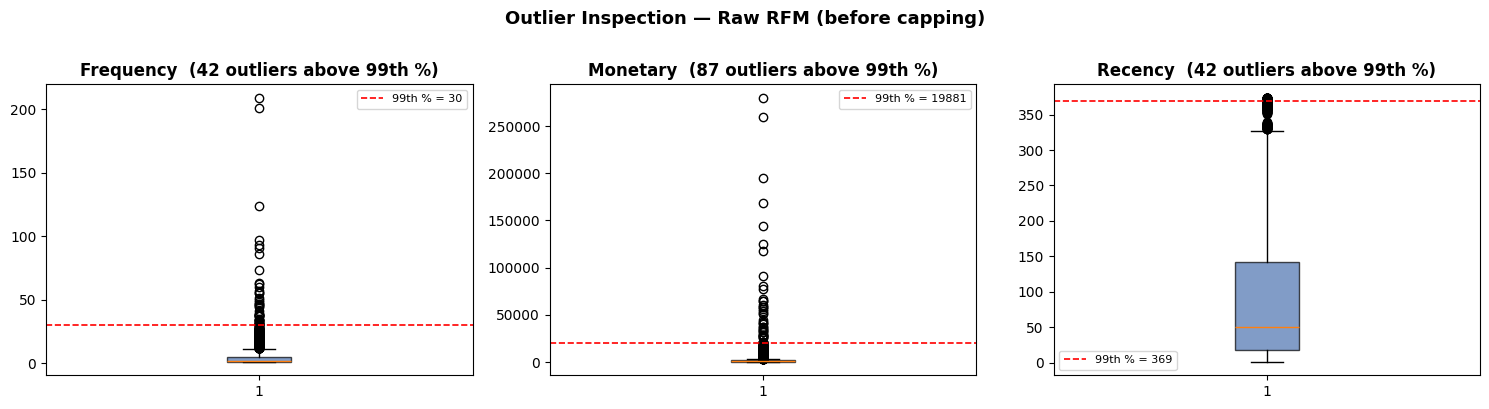

In [24]:
features = ['Frequency' , 'Monetary' , 'Recency']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, features):
    q99 = rfm[feat].quantile(0.99)
    q01 = rfm[feat].quantile(0.01)
    n_out = ((rfm[feat] > q99) | (rfm[feat] < q01)).sum()
    ax.boxplot(rfm[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.7))
    ax.axhline(q99, color="red",    linestyle="--", linewidth=1.2, label=f"99th % = {q99:.0f}")
    ax.set_title(f"{feat}  ({n_out} outliers above 99th %)", fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Outlier Inspection — Raw RFM (before capping)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [25]:
rfm_cap = rfm.copy()

for f in ["Recency", "Frequency", "Monetary"]:
  q_three = rfm_cap[f].quantile(0.99)
  q_one = rfm_cap[f].quantile(0.01)
  before = rfm_cap[f].describe()[['min' , 'max']].to_dict()
  rfm_cap[f] = rfm_cap[f].clip(lower = q_one , upper = q_three)
  after = rfm_cap[f].describe()[['min' , 'max']].to_dict()

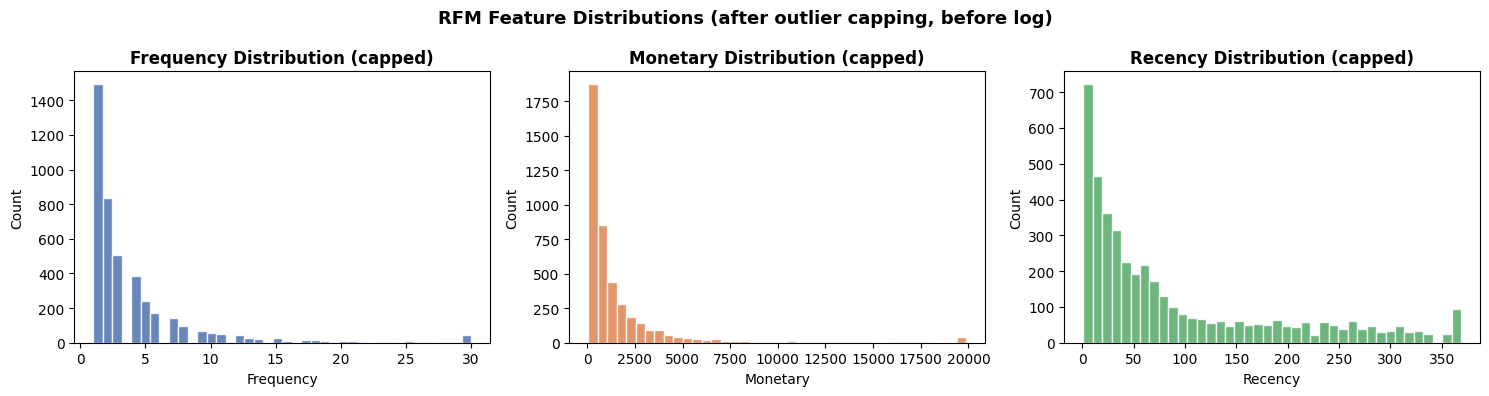

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, color in zip(axes, features, ["#4C72B0","#DD8452","#55A868"]):
    ax.hist(rfm_cap[feat], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{feat} Distribution (capped)", fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")

plt.suptitle("RFM Feature Distributions (after outlier capping, before log)", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()


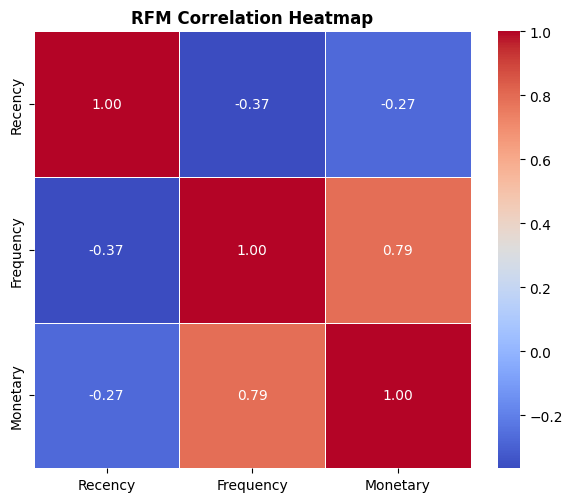

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = rfm_cap[["Recency", "Frequency", "Monetary"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,linewidths=0.5, ax=ax)
ax.set_title("RFM Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
rfm_log = rfm_cap[["Recency", "Frequency", "Monetary"]].apply(np.log1p)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled_arr  = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled_arr , columns = ["Recency", "Frequency", "Monetary"] )

In [30]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.34,-0.97,-2.16
25%,-0.66,-0.97,-0.71
50%,0.09,-0.36,-0.06
75%,0.84,0.68,0.68
max,1.55,3.15,2.73


In [31]:
rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.462228,-0.974100,2.726005
1,-2.038890,1.110952,1.466120
2,0.373218,0.404045,0.745485
3,-0.623084,-0.974100,0.727090
4,1.424788,-0.974100,-0.638518


# PART 3: Finding the Optimal Number of Clusters (k)

In [32]:
from sklearn.cluster import KMeans
inertia = []
for i in range(2,11):
  model = KMeans(n_clusters = i , random_state = 77 , n_init = 10)
  model.fit(rfm_scaled)
  inertia.append(model.inertia_)
for k, val in zip(range(2,11), inertia):
    print(f"k={k} = {val:.2f}")

k=2 = 6319.60
k=3 = 4712.48
k=4 = 3772.42
k=5 = 3155.97
k=6 = 2706.16
k=7 = 2420.27
k=8 = 2209.05
k=9 = 2035.17
k=10 = 1885.29


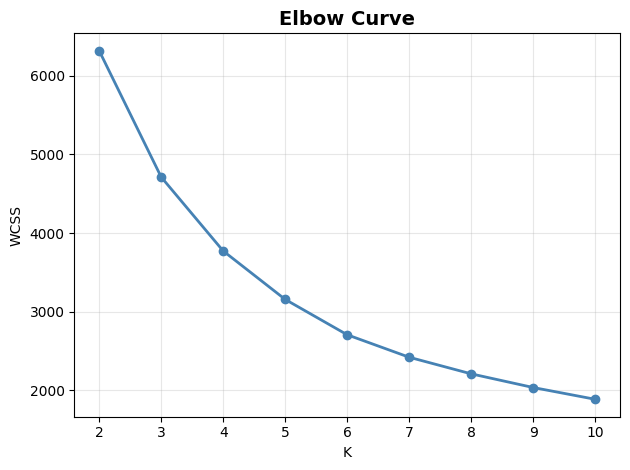

In [33]:
plt.plot(range(2, 11), inertia, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Curve', fontsize=14, fontweight='bold')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import silhouette_score

sil = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=77, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    score  = silhouette_score(rfm_scaled, labels)
    sil.append(score)
    print(f"k={k} ={score:.4f}")

k=2 =0.4362
k=3 =0.3395
k=4 =0.3393
k=5 =0.3160
k=6 =0.3143
k=7 =0.3122
k=8 =0.3058
k=9 =0.2842
k=10 =0.2825


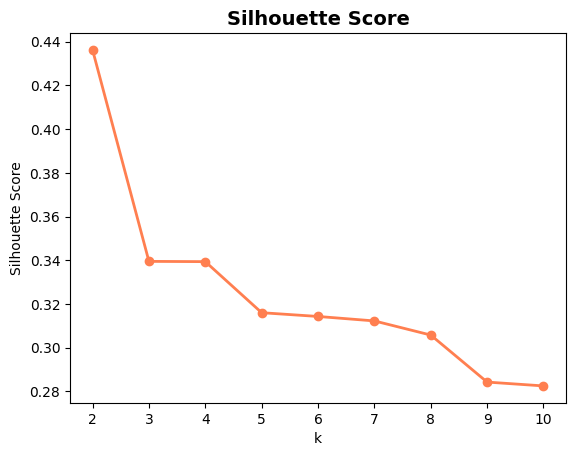

In [35]:
plt.plot(range(2, 11), sil, marker='o', linewidth=2, color='coral')
plt.title('Silhouette Score', fontsize=14, fontweight='bold')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

In [36]:
from sklearn.metrics import calinski_harabasz_score
chs = []
for i in range(2,11):
  model = KMeans(n_clusters = i , random_state = 77 , n_init = 10)
  labels = model.fit_predict(rfm_scaled)
  score2 = calinski_harabasz_score(rfm_scaled , labels)
  chs.append(score2)
  print(f"k={i} ={score2:.4f}")

k=2 =4593.1572
k=3 =3818.3536
k=4 =3539.1442
k=5 =3383.6554
k=6 =3300.1691
k=7 =3159.5788
k=8 =3025.5707
k=9 =2919.2143
k=10 =2838.6620


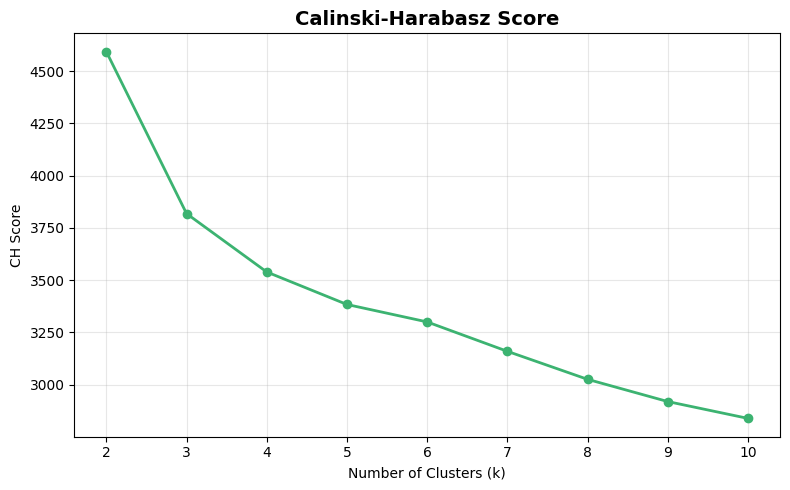

In [37]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), chs, marker='o', linewidth=2, color='mediumseagreen')
plt.title('Calinski-Harabasz Score', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('CH Score')
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PART 4: Clustering & Visualization


In [38]:
final_km = KMeans(n_clusters= 4 , random_state= 42, n_init=25)
final_labels = final_km.fit_predict(rfm_scaled)
rfm_result = rfm_cap.copy()
rfm_result["Cluster_Raw"] = final_labels
print(rfm_result["Cluster_Raw"].value_counts().sort_index().to_string())

Cluster_Raw
0    1173
1     838
2    1591
3     736


In [39]:
centroids = pd.DataFrame(final_km.cluster_centers_,columns=features)
print(centroids)

   Frequency  Monetary   Recency
0   0.133943  0.334669  0.538374
1  -0.805935 -0.410659 -0.437406
2   0.902199 -0.791659 -0.812660
3  -1.245071  1.643980  1.394871


Segment Assignment:
  Cluster 0 → Loyal Customers      | n=1173 (27.0%)
  Cluster 1 → At-Risk              | n= 838 (19.3%)
  Cluster 2 → Lost / Inactive      | n=1591 (36.7%)
  Cluster 3 → Champions            | n= 736 (17.0%)


<Figure size 600x100 with 0 Axes>

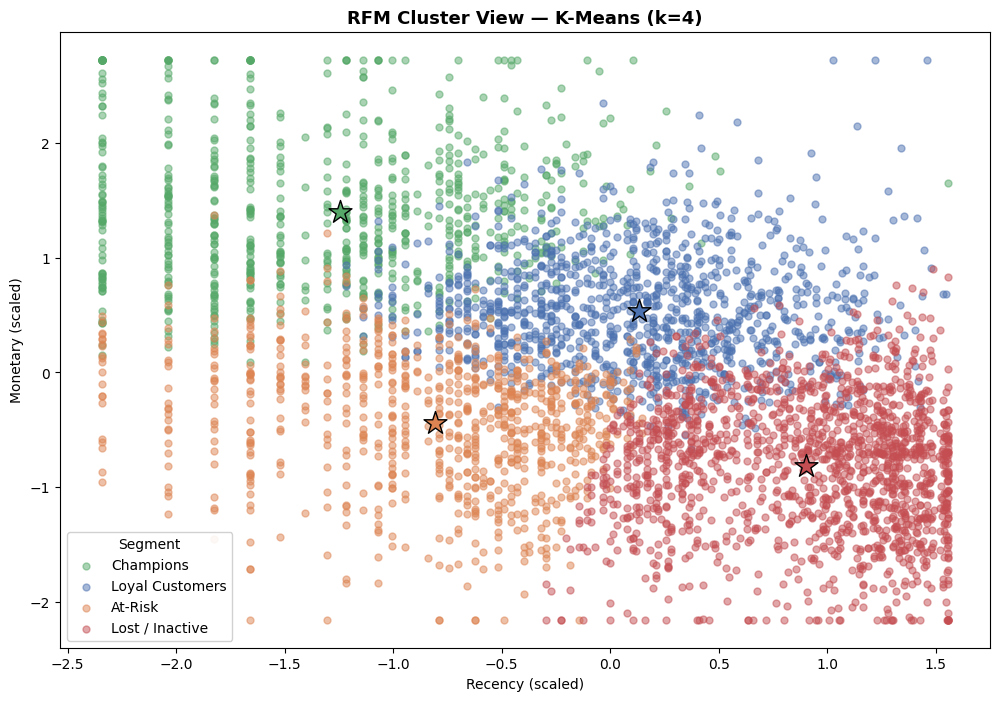

In [46]:
plt.figure(figsize=(6, 1))
profile = rfm_result.groupby("Cluster_Raw")[["Recency","Frequency","Monetary"]].agg(["mean","median"])
profile.columns = ["_".join(c) for c in profile.columns]
profile["Size"]  = rfm_result["Cluster_Raw"].value_counts().sort_index()
profile["Size%"] = (profile["Size"] / len(rfm_result) * 100).round(1)

cluster_order = profile["Monetary_mean"].sort_values(ascending=False).index.tolist()

SEGMENT_NAMES = {}
SEGMENT_COLORS = {}
labels_raw     = ["Champions", "Loyal Customers", "At-Risk", "Lost / Inactive"]
colors_raw     = ["#55A868",   "#4C72B0",          "#DD8452", "#C44E52"]

for rank, (raw_id, name, color) in enumerate(zip(cluster_order, labels_raw, colors_raw)):
    SEGMENT_NAMES[raw_id]  = name
    SEGMENT_COLORS[raw_id] = color

rfm_result["Segment"] = rfm_result["Cluster_Raw"].map(SEGMENT_NAMES)

print("Segment Assignment:")
for cid in sorted(SEGMENT_NAMES):
    n = (rfm_result["Cluster_Raw"] == cid).sum()
    pct = n / len(rfm_result) * 100
    print(f"  Cluster {cid} → {SEGMENT_NAMES[cid]:<20} | n={n:>4} ({pct:.1f}%)")
fig, ax = plt.subplots(figsize=(12, 8))

for cid, seg_name in SEGMENT_NAMES.items():
    mask = rfm_result["Cluster_Raw"] == cid
    ax.scatter(
        rfm_scaled.loc[mask, "Recency"],
        rfm_scaled.loc[mask, "Monetary"],
        c=SEGMENT_COLORS[cid], label=seg_name,
        alpha=0.5, s=25
    )

# Centroids
for cid, center in enumerate(final_km.cluster_centers_):
    ax.scatter(
        center[0], center[2],          # Recency=0, Monetary=2
        c=SEGMENT_COLORS[cid],
        s=300, marker="*", edgecolors="black", linewidths=1, zorder=5
    )

ax.set_xlabel("Recency (scaled)")
ax.set_ylabel("Monetary (scaled)")
ax.set_title("RFM Cluster View — K-Means (k=4)", fontweight="bold", fontsize=13)
ax.legend(title="Segment", framealpha=0.9)
# plt.tight_layout()
plt.show()

In [41]:
display(rfm_result.head())

,CustomerID,Frequency,Monetary,Recency,Cluster_Raw,Segment
0,12346.0,1,19880.9957,326,0,Loyal Customers
1,12347.0,7,4310.0000,2,3,Champions
2,12348.0,4,1797.2400,75,0,Loyal Customers
3,12349.0,1,1757.5500,19,1,At-Risk
4,12350.0,1,334.4000,310,2,Lost / Inactive


In [42]:
display(profile[['Recency_mean', 'Frequency_mean', 'Monetary_mean']].round(2))

,Recency_mean,Frequency_mean,Monetary_mean
Cluster_Raw,,,
0,71.01,4.07,1700.95
1,19.13,2.07,531.96
2,184.14,1.32,342.27
3,12.19,11.94,5366.68
